**Tools for plotting nets as geometric transformations of a data distribution**

Author: Phillip Isola

Last updated: October 2024


In [1]:
# installs
%pip install celluloid
%pip install modula

# imports
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import matplotlib.font_manager as font_manager

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from celluloid import Camera
from typing import *

import matplotlib.pyplot as plt
import seaborn as sns
import dataclasses
from tqdm.auto import tqdm
import numpy as np

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.utils import make_grid
import torchvision
from torch.utils.data import DataLoader

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.mps.is_available() else "cpu"
)
import time

# setup directories
layer_embeddings_viz_dir = "./"
vid_dir = "./"

SyntaxError: invalid syntax (163630395.py, line 36)

In [4]:
from google.colab import drive

In [5]:
# drive.mount('/content')

KeyboardInterrupt: 

In [34]:
device

device(type='cuda')

In [2]:
# define net


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.l1 = torch.nn.Linear(3, 2, bias=False)
        self.relu1 = nn.ReLU()
        self.l2 = torch.nn.Linear(3, 2, bias=False)
        self.relu2 = nn.ReLU()
        self.l3 = torch.nn.Linear(3, 2, bias=False)
        self.softmax = nn.Softmax(dim=1)
        self.layer_names = ["linear", "relu", "linear", "relu", "linear", "softmax"]

    def forward(self, x):

        output = x.view(1, x.size(0), x.size(1))
        for layer in net.children():
            if isinstance(layer, nn.Linear):
                input = torch.cat(
                    [output[-1], torch.ones([x.size(0), 1])], dim=1
                )  # for bias
            else:
                input = output[-1]
            new_output = layer(input).view(1, input.size(0), x.size(1))
            output = torch.cat((output, new_output), axis=0)

        return output

    def forward_grid(self, x):
        # applies each layer separately to the input x, rather than in sequence

        output = x.view(1, x.size(0), x.size(1))
        for layer in net.children():
            if isinstance(layer, nn.Linear):
                input = torch.cat([x, torch.ones([x.size(0), 1])], dim=1)  # for bias
            else:
                input = x
            new_output = layer(input).view(1, input.size(0), x.size(1))
            output = torch.cat((output, new_output), axis=0)

        return output

    def get_layer_name(self, l):
        return self.layer_names[l]


def weights_init(m):
    if isinstance(m, nn.Linear):
        m.reset_parameters()
        torch.nn.init.eye_(m.weight.data)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)


def computeLoss(net, criterion, X, Y):
    output = net(X)
    loss = criterion(torch.log(output[-1]), Y)
    return loss


def trainForABit(net, criterion, optimizer, X, Y, N_train_iter_per_viz):
    for jj in range(N_train_iter_per_viz):
        optimizer.zero_grad()
        loss = computeLoss(net, criterion, X, Y)
        loss.backward()
        optimizer.step()
    return loss


def trainForABit_keller(net, criterion, optimizer, X, Y, N_train_iter_per_viz, lr):
    for jj in range(N_train_iter_per_viz):
        net.zero_grad()
        loss = computeLoss(net, criterion, X, Y)
        loss.backward()
        for layer in net.children():
            if isinstance(layer, nn.Linear):
                with torch.no_grad():
                    G = layer.weight.grad.data
                    O = zeroth_power_via_newtonschulz5(G)
                    layer.weight -= lr * O
    return loss


@torch.compile
def zeroth_power_via_newtonschulz5(G, steps=5, eps=1e-7):
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.bfloat16() / (G.norm() + eps)
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = A @ X
        X = a * X + b * B + c * A @ B
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(G.dtype)

In [3]:
# create toy data
def mk_dataset():

    Nsamples = 50

    # center circle
    mean = (0, 0)
    cov = [[0.02, 0], [0, 0.02]]
    X = np.random.multivariate_normal(mean, cov, (Nsamples))
    Y = np.zeros(Nsamples)

    # surrounding moon
    xx = np.linspace(-np.pi / 4, np.pi - np.pi / 4, Nsamples)
    X2 = 0.75 * np.stack([np.sin(xx), np.cos(xx)], axis=1)
    mean = (0, 0)
    cov = [[0.02, 0], [0, 0.02]]
    X2 += np.random.multivariate_normal(mean, cov, (Nsamples))
    Y2 = np.ones(Nsamples)

    X = np.concatenate([X, X2], axis=0)
    Y = np.concatenate([Y, Y2], axis=0)

    X = torch.tensor(X.astype(np.float32))
    Y = torch.tensor(Y.astype(np.int_))

    return X, Y

In [4]:
def vizMapping(X, Y, grid_us, grid_vs, loss, z_offset, ax):

    # create flattened data for samples in grid
    grid_flat = np.stack((grid_us, grid_vs), axis=2)
    grid_flat = np.reshape(
        grid_flat, (grid_flat.shape[0] * grid_flat.shape[1], grid_flat.shape[2])
    )  # grid_flat: Nsamples x Nfeats
    grid_flat = torch.tensor(grid_flat.astype(np.float32))

    # run net on the data and on the grid
    output = net(X).detach().numpy()  # Nlayers x Nsamples x Nfeats
    output_grid = (
        net.forward_grid(grid_flat).detach().numpy()
    )  # Nlayers x Nsamples x Nfeats

    n_layers = output.shape[0]
    n_classes = len(np.unique(Y))

    for l in range(n_layers):
        # plot grid
        ax.plot_wireframe(
            np.reshape(output_grid[l, :, 0], [2, 2]),
            np.reshape(-output_grid[l, :, 1], [2, 2]),
            (l * z_step) * np.ones_like(np.reshape(output_grid[l, :, 0], [2, 2]))
            + z_offset,
            rcount=1,
            ccount=1,
            color=[0.7, 0.7, 0.7],
            linewidth=3.0,
            linestyle="--",
            zorder=2 * l + 0.0001,
        )
        ax.plot_surface(
            grid_us,
            grid_vs,
            (l * z_step) * np.ones_like(grid_us) + z_offset,
            rcount=1,
            ccount=1,
            color=[1.0, 1.0, 1.0],
            shade=False,
            linewidth=0,
            zorder=2 * l + 0.001,
            alpha=0.75,
        )
        ax.plot_wireframe(
            grid_us,
            grid_vs,
            (l * z_step) * np.ones_like(grid_us) + z_offset,
            rcount=1,
            ccount=1,
            color=[0.3, 0.3, 0.3],
            linewidth=6.0,
            zorder=2 * l + 0.01,
        )
        ax.plot(
            [min_u, max_u],
            [0, 0],
            [l * z_step + z_offset, l * z_step + z_offset],
            color=[0.5, 0.5, 0.5],
            linewidth=4.0,
            zorder=2 * l,
        )
        ax.plot(
            [0, 0],
            [min_v, max_v],
            [l * z_step + z_offset, l * z_step + z_offset],
            color=[0.5, 0.5, 0.5],
            linewidth=4.0,
            zorder=2 * l,
        )

        # plot grid mapping
        if l < (n_layers - 1):
            for i in range(0, output_grid.shape[1], 1):
                ax.plot(
                    [grid_flat[i, 0], output_grid[l + 1, i, 0]],
                    [-grid_flat[i, 1], -output_grid[l + 1, i, 1]],
                    [l * z_step + z_offset, (l + 1) * z_step + z_offset],
                    "--",
                    marker="o",
                    color=[0.7, 0.7, 0.7],
                    linewidth=3,
                    markersize=10,
                    zorder=2 * l + 1,
                )  # , alpha=.1)
                ax.scatter(
                    output_grid[l + 1, i, 0],
                    -output_grid[l + 1, i, 1],
                    (l + 1) * z_step + z_offset,
                    marker=">",
                    color=[0.1, 0.1, 0.1],
                    s=80,
                    zorder=2 * l + 1.01,
                )

            # display layer name
            font_prop = font_manager.FontProperties(size=24)
            ax.text(
                -z_step,
                0,
                (l + 1) * z_step + z_offset,
                net.get_layer_name(l),
                fontproperties=font_prop,
            )

        # plot data
        for i in range(output.shape[1]):
            if Y[i] == 0:
                color = np.array([255, 0, 0, 255]) / 255
            else:
                color = np.array([0, 0, 255, 255]) / 255

            if Y[i] == 0:
                if l < n_layers - 1:
                    ax.plot(
                        [output[l, i, 0], output[l + 1, i, 0]],
                        [-output[l, i, 1], -output[l + 1, i, 1]],
                        [l * z_step + z_offset, (l + 1) * z_step + z_offset],
                        "--",
                        marker=".",
                        color=color,
                        linewidth=3,
                        markersize=0,
                        zorder=2 * l + 1,
                        alpha=0.5,
                    )
                ax.scatter(
                    output[l, i, 0].ravel(),
                    -output[l, i, 1].ravel(),
                    (l) * z_step + z_offset,
                    color=color,
                    s=160,
                    alpha=0.5,
                    linewidth=0,
                    zorder=2 * l + 1.01,
                )
            else:
                if l < n_layers - 1:
                    ax.plot(
                        [output[l, i, 0], output[l + 1, i, 0]],
                        [-output[l, i, 1], -output[l + 1, i, 1]],
                        [l * z_step + z_offset, (l + 1) * z_step + z_offset],
                        "--",
                        marker=".",
                        color=color,
                        linewidth=3,
                        markersize=0,
                        zorder=2 * l + 1,
                        alpha=0.5,
                    )
                ax.scatter(
                    output[l, i, 0].ravel(),
                    -output[l, i, 1].ravel(),
                    (l) * z_step + z_offset,
                    color=color,
                    s=160,
                    alpha=0.5,
                    linewidth=0,
                    zorder=2 * l + 1.01,
                )

    # display loss
    font_prop = font_manager.FontProperties(size=24)
    ax.text(
        -z_step / 4,
        0,
        (n_layers - 0.2) * z_step + z_offset,
        "Loss: {:.2f}".format(loss),
        fontproperties=font_prop,
    )

    ax.set_xlim3d(-2 * n_layers / 2, 2 * n_layers / 2)
    ax.set_ylim3d(-2 * n_layers / 2, 2 * n_layers / 2)
    ax.set_zlim3d(-0.5, 2 * n_layers)
    ax.set_axis_off()

loss: 0.7068834900856018
loss: 0.5570662617683411
loss: 0.4715787172317505
loss: 0.3892751634120941
loss: 0.31626415252685547
loss: 0.25217577815055847
loss: 0.19913500547409058
loss: 0.1602454036474228
loss: 0.13252460956573486
loss: 0.1123621016740799


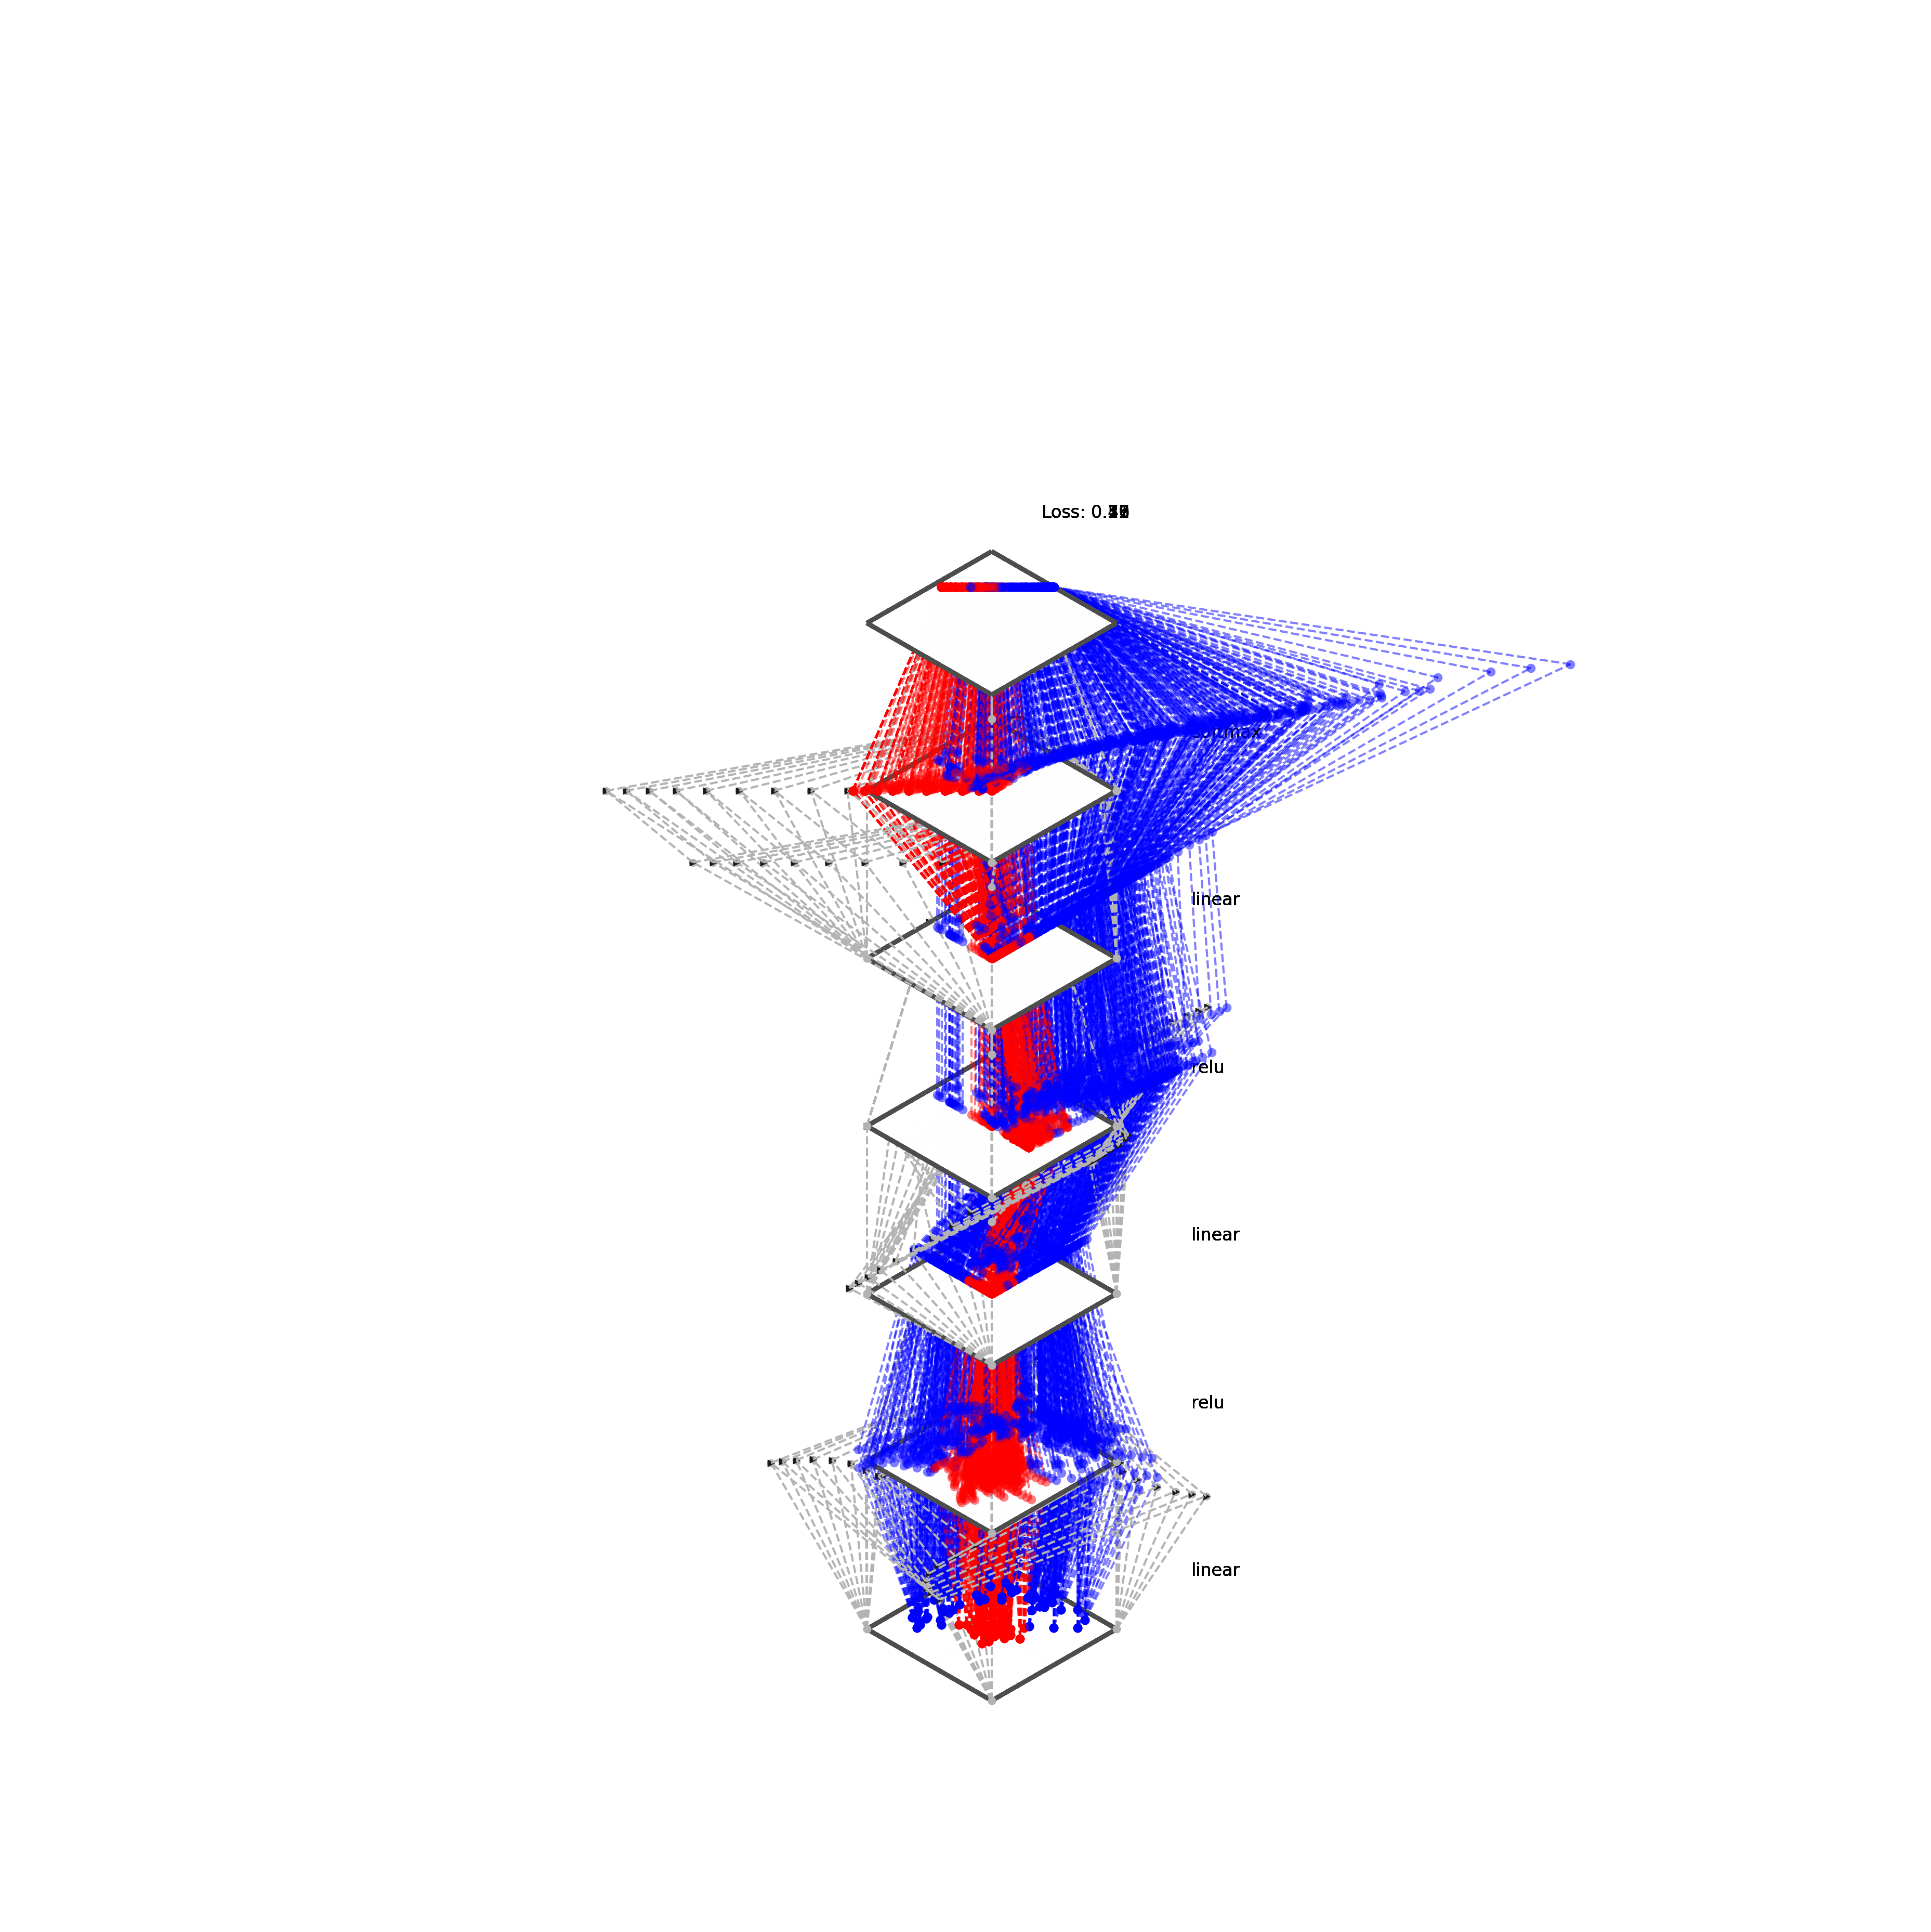

In [5]:
# seed (for replicability)
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

# setup figure
fig = plt.figure()
fig.set_size_inches(48, 48, forward=True)
ax = fig.add_subplot(111, projection="3d", proj_type="ortho", computed_zorder=False)
ax.view_init(elev=35, azim=135)
ax.dist = 8

# setup camera
camera = Camera(fig)  # for recording videos

# plotting parameters
max_u, max_v = 1, 1
min_u, min_v = -1, -1
z_step = 3.2

# make dataset
X, Y = mk_dataset()

# setup grid for visualization
grid_us, grid_vs = np.meshgrid(
    np.linspace(min_u, max_u, num=2), np.linspace(min_v, max_v, num=2)
)

# train
net = Net()
net.apply(weights_init)  # re-initialize net
criterion = nn.NLLLoss()
lr = 0.01
optimizer = optim.SGD(net.parameters(), lr=lr)
N_viz_iter = 10
N_train_iter_per_viz = 250

output = net(X).detach().numpy()  # Nlayers x Nsamples x Nfeats
n_layers = output.shape[0]
z_offset = -z_step * ((n_layers - 3) / 2)

record_type = (
    "vid"  # can't seem to get both video and individual frames to work simultaneously,
)
#  so just select which type of recording you want here

for ii in range(N_viz_iter):
    # get current loss
    loss = computeLoss(net, criterion, X, Y)
    if (ii % 1) == 0:
        print("loss: {}".format(loss))

    # viz
    vizMapping(X, Y, grid_us, grid_vs, loss, z_offset, ax)
    if record_type == "frames":
        plt.savefig(vid_dir + "/{}.png".format(ii))
        ax.clear()
    elif record_type == "vid":
        camera.snap()

    # train
    trainForABit(net, criterion, optimizer, X, Y, N_train_iter_per_viz)
    # trainForABit_keller(net, criterion, optimizer, X, Y, N_train_iter_per_viz,lr)

In [6]:
animation = camera.animate()
animation.save(vid_dir + "./animation.mp4")

In [7]:
!pwd

/content


In [8]:
!ls -la

total 1628
drwxr-xr-x 1 root root    4096 Aug 10 01:59 .
drwxr-xr-x 1 root root    4096 Aug 10 01:48 ..
-rw-r--r-- 1 root root 1646273 Aug 10 02:00 animation.mp4
drwxr-xr-x 4 root root    4096 Jun  4 13:39 .config
drwxr-xr-x 5 root root    4096 Aug 10 01:53 pycharm-libs
drwxr-xr-x 1 root root    4096 Jun  4 13:39 sample_data


In [9]:
!cp animation.mp4 ./sample_data

In [10]:
from google.colab import drive

drive.mount("/content/drive")

KeyboardInterrupt: 

In [11]:
from google.colab import files

In [12]:
files.download("animation.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
!curl --upload-file ./animation.mp4 https://transfer.sh

curl: (7) Failed to connect to transfer.sh port 443 after 167 ms: Connection refused
